# Timing Strategy Calibration

Goal: identify the Pareto-efficient timing strategy parameters to use in Phase 1.

## Method
Replicates Mariska's (2024) parameter space across all three strategy types:
- **Baseline**: FCFS only (periodic RF=100,000s — solver never fires)
- **Periodic**: 5 values of periodic_rf
- **Event-Driven**: 32 combinations of event_driven_rf x controller_freq x threshold_confidence
- **Hybrid**: 48 combinations adding periodic_rf

All runs use:
- No priority (weight_passenger=1, weight_freight=1)
- Objective: final_delay
- Freight: 15% (N_FREIGHT=182)
- GAMMA: calibrated value from calibrate_gamma.ipynb
- 50 seeds per configuration

## Output
One folder per configuration under `results/calibration/timing/`:
- `<config_name>_seed<N>.parquet` — full df per seed, for reanalysis
- `raw_runs.csv` — metrics per seed
- `aggregated.csv` — mean and std over all seeds

The folder name is built by `run_simulation._build_config_name` and is
strategy-specific (no irrelevant parameters included).

## Resuming after interruption
Completed configurations are skipped automatically based on `aggregated.csv`.
To rerun a configuration: delete its folder under `results/calibration/timing/`.

## Selection criterion
Pareto-efficient strategies on TED_combined vs total_solve_time.
The best-of-type strategy per strategy type is carried forward to Phase 1.


## Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_simulation
from utils.metrics import (
    compute_metrics, build_result_row,
    save_result_row, aggregate_config, load_all_aggregated
)

print('Imports OK')

Imports OK


## Parameters

In [2]:
# --- Fixed parameters ---
N_FREIGHT          = 182     # 15% of total fleet
FREIGHT_PCT        = 0.15
N_RUNS             = 50      # seeds per configuration
GAMMA              = 120     # s — calibrated from calibrate_gamma.ipynb
MC_DELAY_PER_TRAIN = 40      # s — per active train MC threshold
SOLVER_TIMEOUT     = 60      # s
OBJECTIVE          = 'static'  # no priority, final_delay objective
WEIGHT_PASSENGER   = 1
WEIGHT_FREIGHT     = 1

# --- Output ---
RESULTS_DIR = Path('../results/calibration/timing')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'N_RUNS:             {N_RUNS}')
print(f'N_FREIGHT:          {N_FREIGHT}')
print(f'GAMMA:              {GAMMA}s')
print(f'MC_DELAY_PER_TRAIN: {MC_DELAY_PER_TRAIN}s')
print(f'Results dir:        {RESULTS_DIR.resolve()}')

N_RUNS:             50
N_FREIGHT:          182
GAMMA:              120s
MC_DELAY_PER_TRAIN: 40s
Results dir:        /Users/ddw/Desktop/Rescheduling/results/calibration/timing


## Configuration Grid

Each config dict maps directly to `run_simulation()` keyword arguments.
Derived from Table 8 in Vande Sompele (2024).

Note: `event_driven_freq`, `controller_freq`, `periodic_freq` and
`threshold_confidence` default to the values in `run_simulation.py`
when not overridden — we always pass them explicitly for clarity.

In [ ]:
configs = []
# -----------------------------------------------------------------------
# Baseline — FCFS only, solver never fires
# -----------------------------------------------------------------------
configs.append({
    'trigger_strategy':     'periodic',
    'periodic_freq':        100_000,
    'event_driven_freq':    900,
    'controller_freq':      300,
    'threshold_confidence': 0.6,
})
# -----------------------------------------------------------------------
# Periodic — 7 values
# -----------------------------------------------------------------------
for prf in [450, 900, 1800, 3600]:
    configs.append({
        'trigger_strategy':     'periodic',
        'periodic_freq':        prf,
        'event_driven_freq':    900,
        'controller_freq':      300,
        'threshold_confidence': 0.6,
    })
# -----------------------------------------------------------------------
# # Event-Driven — inclusief nieuwe edf=600 configs
# # -----------------------------------------------------------------------
ed_rf_cf_map = {
    600:  [300, 600],
    900:  [450, 900],
    1800: [450, 900, 1800],
    3600: [900, 1800, 3600],
    5400: [1800, 3600, 5400],
}
tc_values = [0.4, 0.8]
for ed_rf, cf_list in ed_rf_cf_map.items():
    for cf in cf_list:
        for tc in tc_values:
            configs.append({
                'trigger_strategy':     'event_driven',
                'event_driven_freq':    ed_rf,
                'controller_freq':      cf,
                'threshold_confidence': tc,
                'periodic_freq':        100_000,
            })
# -----------------------------------------------------------------------
# Hybrid — bestaande + nieuwe met ed_rf=900 en ed_rf=600
# -----------------------------------------------------------------------
hybrid_combos = [
    # --- bestaand ---
    (1800, 900,  3600), 
    (1800, 900,  5400), 
    (1800, 900,  7200), 
    (3600, 900,  5400), (3600, 1800, 5400), 
    (3600, 900,  7200), (3600, 1800, 7200), 
    (5400, 900,  7200), (5400, 1800, 7200),
    # --- nieuw: ed_rf=900 ---
    (900, 450, 1800), (900, 450, 3600),
]
for ed_rf, cf, prf in hybrid_combos:
    for tc in tc_values:
        configs.append({
            'trigger_strategy':     'hybrid',
            'event_driven_freq':    ed_rf,
            'controller_freq':      cf,
            'periodic_freq':        prf,
            'threshold_confidence': tc,
        })
# -----------------------------------------------------------------------
# Tellen
# -----------------------------------------------------------------------
n_baseline     = sum(1 for c in configs if c['trigger_strategy'] == 'periodic' and c['periodic_freq'] == 100_000)
n_periodic     = sum(1 for c in configs if c['trigger_strategy'] == 'periodic' and c['periodic_freq'] != 100_000)
n_event_driven = sum(1 for c in configs if c['trigger_strategy'] == 'event_driven')
n_hybrid       = sum(1 for c in configs if c['trigger_strategy'] == 'hybrid')
print(f'Total configurations: {len(configs)}')
print(f'  Baseline:     {n_baseline}')
print(f'  Periodic:     {n_periodic}')
print(f'  Event-Driven: {n_event_driven}  (+6 nieuw: edf=600 × 2 cf × 3 tc)')
print(f'  Hybrid:       {n_hybrid}  (+12 nieuw: ed_rf=900/600 × 4 combos × 3 tc)')
print(f'\nTotal runs: {len(configs)} x {N_RUNS} = {len(configs) * N_RUNS}')

Total configurations: 8
  Baseline:     1
  Periodic:     7
  Event-Driven: 0  (+6 nieuw: edf=600 × 2 cf × 3 tc)
  Hybrid:       0  (+12 nieuw: ed_rf=900/600 × 4 combos × 3 tc)

Total runs: 8 x 50 = 400


## Run All Configurations

For each configuration:
1. Call `run_simulation(save=True)` — parquet saved per seed, `config_dir` returned
2. Compute metrics from `df` via `compute_metrics`
3. Append metrics row to `raw_runs.csv` via `save_result_row`
4. After all seeds: aggregate to `aggregated.csv` via `aggregate_config`

Skip logic: if `aggregated.csv` already exists in the config folder,
that configuration is skipped. Safe to interrupt and restart.

In [4]:
for config_idx, cfg in enumerate(configs):

    # Build run_simulation kwargs from config dict
    sim_kwargs = dict(
        n_freight            = N_FREIGHT,
        trigger_strategy     = cfg['trigger_strategy'],
        event_driven_freq    = cfg['event_driven_freq'],
        controller_freq      = cfg['controller_freq'],
        periodic_freq        = cfg['periodic_freq'],
        threshold_confidence = cfg['threshold_confidence'],
        objective_strategy   = OBJECTIVE,
        weight_passenger     = WEIGHT_PASSENGER,
        weight_freight       = WEIGHT_FREIGHT,
        dynamic_threshold    = GAMMA,
        mc_delay_per_train   = MC_DELAY_PER_TRAIN,
        output_dir           = RESULTS_DIR,
        save                 = True,
    )

    # Determine config_dir by doing a dry seed=0 call to get the name,
    # then check if aggregated.csv already exists — skip if so.
    # We infer the config dir from the first seed's return value.
    # If aggregated.csv exists inside any matching subfolder, skip.
    # Simple and robust: just check seed 0 parquet existence.
    # Build expected config_dir using same logic as run_simulation
    from run_simulation import _build_config_name
    params_check = {
        'n_freight':           N_FREIGHT,
        'trigger_strategy':    cfg['trigger_strategy'],
        'event_driven_freq':   cfg['event_driven_freq'],
        'controller_freq':     cfg['controller_freq'],
        'periodic_freq':       cfg['periodic_freq'],
        'threshold_confidence':cfg['threshold_confidence'],
        'objective_strategy':  OBJECTIVE,
        'mc_delay_per_train':   MC_DELAY_PER_TRAIN,   # ← toevoegen
        'weight_passenger':    WEIGHT_PASSENGER,
        'weight_freight':      WEIGHT_FREIGHT,
        'dynamic_threshold':   GAMMA,
        'seed':                0,
    }
    config_dir = RESULTS_DIR / _build_config_name(params_check)

    # Skip volledige configuratie indien map al bestaat
    if config_dir.exists():
        print(f'[{config_idx+1}/{len(configs)}] SKIP: {config_dir.name} already exists')
        continue

    # Anders map aanmaken
    config_dir.mkdir(parents=True, exist_ok=True)

    print(f'\n[{config_idx+1}/{len(configs)}] Running: {config_dir.name}')

    for seed in range(N_RUNS):
        state, df, meta, config_dir = run_simulation(seed=seed, **sim_kwargs)

        if meta["deadlock_detected"]:
            print(f"  Seed {seed} → DEADLOCK (uitgesloten van analyse)")
            # Sla een marker op zodat je weet welke seeds deadlockten
            deadlock_row = build_result_row(
                seed               = seed,
                phase              = 0,
                metrics            = {"TED_combined": None, "TED_passenger": None,
                                    "TED_freight": None, "delay_ratio": None},
                meta               = meta,
                strategy_type      = cfg['trigger_strategy'],
                periodic_rf        = cfg['periodic_freq']        if cfg['trigger_strategy'] != 'event_driven' else None,
                event_driven_rf    = cfg['event_driven_freq']    if cfg['trigger_strategy'] != 'periodic'     else None,
                controller_freq    = cfg['controller_freq']      if cfg['trigger_strategy'] != 'periodic'     else None,
                threshold_conf     = cfg['threshold_confidence'] if cfg['trigger_strategy'] != 'periodic'     else None,
                priority           = 'no_priority',
                weight_passenger   = WEIGHT_PASSENGER,
                weight_freight     = WEIGHT_FREIGHT,
                gamma              = GAMMA,
                objective          = 'final_delay',
                freight_pct        = FREIGHT_PCT,
                mc_delay_per_train = MC_DELAY_PER_TRAIN,
                solver_timeout     = SOLVER_TIMEOUT,
            )
            # Voeg deadlock marker toe aan de row voor traceerbaarheid
            deadlock_row["deadlock"] = True
            save_result_row(deadlock_row, config_dir=config_dir)
            continue

        metrics = compute_metrics(df)
        row = build_result_row(
            seed               = seed,
            phase              = 0,
            metrics            = metrics,
            meta               = meta,
            strategy_type      = cfg['trigger_strategy'],
            periodic_rf        = cfg['periodic_freq']        if cfg['trigger_strategy'] != 'event_driven' else None,
            event_driven_rf    = cfg['event_driven_freq']    if cfg['trigger_strategy'] != 'periodic'     else None,
            controller_freq    = cfg['controller_freq']      if cfg['trigger_strategy'] != 'periodic'     else None,
            threshold_conf     = cfg['threshold_confidence'] if cfg['trigger_strategy'] != 'periodic'     else None,
            priority           = 'no_priority',
            weight_passenger   = WEIGHT_PASSENGER,
            weight_freight     = WEIGHT_FREIGHT,
            gamma              = GAMMA,
            objective          = 'final_delay',
            freight_pct        = FREIGHT_PCT,
            mc_delay_per_train = MC_DELAY_PER_TRAIN,
            solver_timeout     = SOLVER_TIMEOUT,
        )
        row["deadlock"] = False
        save_result_row(row, config_dir=config_dir)

        if (seed + 1) % 10 == 0:
            print(f'  Seed {seed + 1}/{N_RUNS} completed')

    aggregate_config(config_dir)
    print(f'  Aggregated -> {config_dir.name}')

print('\nAll configurations completed.')


[1/8] Running: n182_periodic_static_wp1_wf1_pf100000
Loading data...
Building controller (trigger=periodic, objective=static)...
Running simulation...
Processing results...
Saved: ../results/calibration/timing/n182_periodic_static_wp1_wf1_pf100000/n182_periodic_static_wp1_wf1_pf100000_seed0.parquet
Done. 10806 rows, 1210 trains.
Controller: {'n_rescheduled': 0, 'n_fcfs_fallback': 0, 'n_skipped': 11099, 'n_evaluated': 0, 'total_steps': 11099, 'total_solver_runtime_s': 0}
Loading data...
Building controller (trigger=periodic, objective=static)...
Running simulation...
Processing results...
Saved: ../results/calibration/timing/n182_periodic_static_wp1_wf1_pf100000/n182_periodic_static_wp1_wf1_pf100000_seed1.parquet
Done. 10806 rows, 1210 trains.
Controller: {'n_rescheduled': 0, 'n_fcfs_fallback': 0, 'n_skipped': 11077, 'n_evaluated': 0, 'total_steps': 11077, 'total_solver_runtime_s': 0}
Loading data...
Building controller (trigger=periodic, objective=static)...
Running simulation...
Proc

KeyboardInterrupt: 

## Load All Results

In [ ]:
df_results = load_all_aggregated(RESULTS_DIR)

# Separate baseline for reference line
df_baseline = df_results[
    (df_results['strategy_type'] == 'periodic') &
    (df_results['periodic_rf'] == 100_000)
]
df_strategies = df_results[
    ~((df_results['strategy_type'] == 'periodic') &
      (df_results['periodic_rf'] == 100_000))
]

print(f'Configurations loaded: {len(df_results)}')
print(f'  Baseline:     {len(df_baseline)}')
print(f'  Strategies:   {len(df_strategies)}')

Configurations loaded: 113
  Baseline:     1
  Strategies:   112


## Pareto Analysis

Identify Pareto-efficient strategies on TED_combined_mean vs total_solve_time_mean.
A strategy is Pareto-efficient if no other strategy is better on both metrics simultaneously.

In [ ]:
def is_pareto_efficient(df, x_col, y_col):
    """Returns boolean list — True if row is Pareto-efficient (minimise both)."""
    vals = df[[x_col, y_col]].values
    efficient = []
    for i, (xi, yi) in enumerate(vals):
        dominated = any(
            vals[j, 0] <= xi and vals[j, 1] <= yi and
            (vals[j, 0] < xi or vals[j, 1] < yi)
            for j in range(len(vals)) if j != i
        )
        efficient.append(not dominated)
    return efficient

df_strategies = df_strategies.copy()
df_strategies['pareto'] = is_pareto_efficient(
    df_strategies, 'TED_combined_mean', 'total_solve_time_mean'
)

print(f'Pareto-efficient strategies: {df_strategies["pareto"].sum()} of {len(df_strategies)}')
print()
print(df_strategies[df_strategies['pareto']][
    ['strategy_type', 'periodic_rf', 'event_driven_rf',
     'controller_freq', 'threshold_conf',
     'TED_combined_mean', 'total_solve_time_mean']
].sort_values('TED_combined_mean').to_string(index=False))

Pareto-efficient strategies: 19 of 112

strategy_type  periodic_rf  event_driven_rf  controller_freq  threshold_conf  TED_combined_mean  total_solve_time_mean
     periodic        300.0              NaN              NaN             NaN       61387.972000               2.195486
     periodic        600.0              NaN              NaN             NaN       71203.964000               1.310672
 event_driven          NaN            600.0            300.0             0.4       73649.968000               0.984852
     periodic        900.0              NaN              NaN             NaN       74336.118750               0.872886
       hybrid       3600.0            600.0            300.0             0.8       75369.456000               0.771975
       hybrid       1800.0            600.0            600.0             0.8       76114.161169               0.737714
 event_driven          NaN            900.0            900.0             0.6       77755.961224               0.632687
 event_d

## Pareto Plot

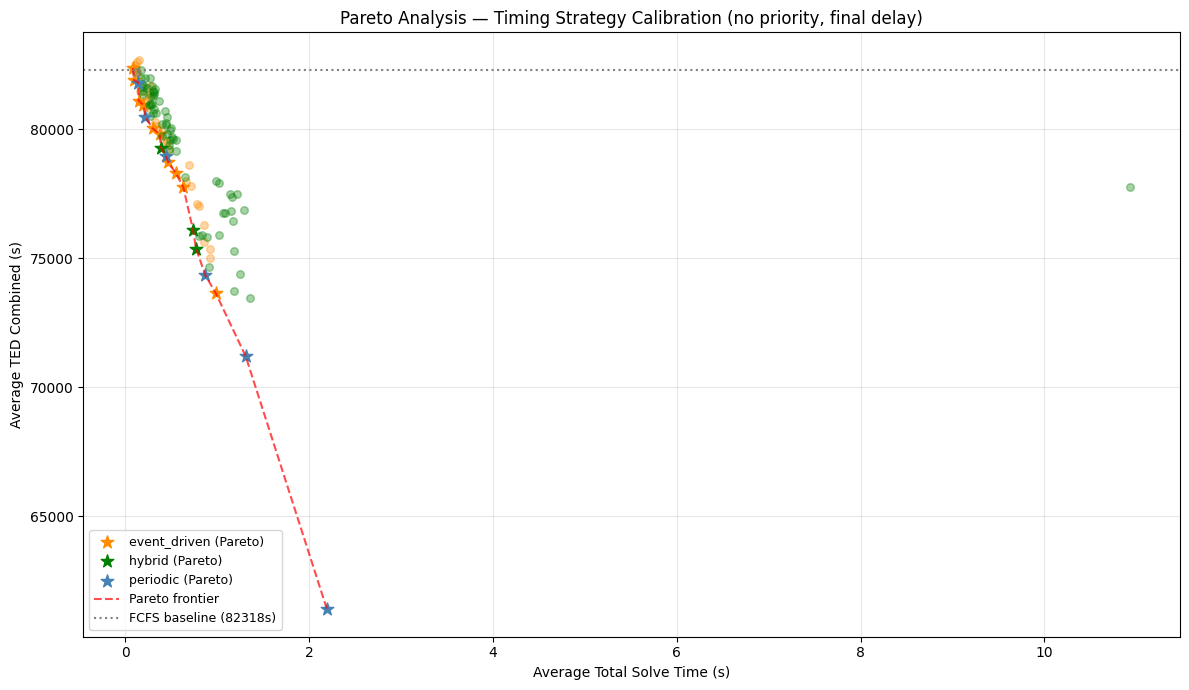

Figure saved: ../results/calibration/timing_MC_delay_120_objective_==/pareto_timing_calibration.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = {
    'periodic':     'steelblue',
    'event_driven': 'darkorange',
    'hybrid':       'green',
}

for strategy, group in df_strategies.groupby('strategy_type'):
    color      = colors.get(strategy, 'black')
    non_pareto = group[~group['pareto']]
    pareto     = group[group['pareto']]

    if len(non_pareto) > 0:
        ax.scatter(
            non_pareto['total_solve_time_mean'],
            non_pareto['TED_combined_mean'],
            color=color, alpha=0.35, s=30,
        )
    if len(pareto) > 0:
        ax.scatter(
            pareto['total_solve_time_mean'],
            pareto['TED_combined_mean'],
            color=color, alpha=1.0, s=90, marker='*',
            label=f'{strategy} (Pareto)',
        )

# Pareto frontier line
pareto_sorted = df_strategies[df_strategies['pareto']].sort_values('total_solve_time_mean')
ax.plot(
    pareto_sorted['total_solve_time_mean'],
    pareto_sorted['TED_combined_mean'],
    color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Pareto frontier'
)

# FCFS baseline horizontal line
if len(df_baseline) > 0:
    baseline_ted = df_baseline['TED_combined_mean'].values[0]
    ax.axhline(
        baseline_ted, color='grey', linestyle=':',
        linewidth=1.5, label=f'FCFS baseline ({baseline_ted:.0f}s)'
    )

ax.set_xlabel('Average Total Solve Time (s)')
ax.set_ylabel('Average TED Combined (s)')
ax.set_title('Pareto Analysis — Timing Strategy Calibration (no priority, final delay)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pareto_timing_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {RESULTS_DIR / "pareto_timing_calibration.png"}')

## Interactive

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

colors = {
    'periodic':     'steelblue',
    'event_driven': 'darkorange',
    'hybrid':       'green',
}


def build_customdata(df):
    return list(zip(
        df['strategy_type'],
        df['periodic_rf'],
        df['event_driven_rf'],
        df['controller_freq'],
        df['threshold_conf'],
    ))


for strategy, group in df_strategies.groupby('strategy_type'):

    color = colors.get(strategy, 'black')

    non_pareto = group[~group['pareto']]
    pareto     = group[group['pareto']]

    # Non-Pareto points
    if len(non_pareto) > 0:

        fig.add_trace(go.Scatter(
            x=non_pareto['total_solve_time_mean'],
            y=non_pareto['TED_combined_mean'],

            mode='markers',

            marker=dict(
                color=color,
                size=7,
                opacity=0.35,
            ),

            name=f'{strategy}',

            customdata=build_customdata(non_pareto),

            hovertemplate=
                "<b>%{customdata[0]}</b><br>" +
                "TED: %{y:.0f}s<br>" +
                "Solve time: %{x:.3f}s<br>" +
                "Periodic freq: %{customdata[1]}<br>" +
                "EDF: %{customdata[2]}<br>" +
                "Controller freq: %{customdata[3]}<br>" +
                "Threshold conf: %{customdata[4]}<br>" +
                "<extra></extra>"
        ))

    # Pareto points
    if len(pareto) > 0:

        fig.add_trace(go.Scatter(
            x=pareto['total_solve_time_mean'],
            y=pareto['TED_combined_mean'],

            mode='markers',

            marker=dict(
                color=color,
                size=14,
                symbol='star',
            ),

            name=f'{strategy} (Pareto)',

            customdata=build_customdata(pareto),

            hovertemplate=
                "<b>%{customdata[0]} — Pareto</b><br>" +
                "TED: %{y:.0f}s<br>" +
                "Solve time: %{x:.3f}s<br>" +
                "Periodic freq: %{customdata[1]}<br>" +
                "EDF: %{customdata[2]}<br>" +
                "Controller freq: %{customdata[3]}<br>" +
                "Threshold conf: %{customdata[4]}<br>" +
                "<extra></extra>"
        ))


# Pareto frontier line
pareto_sorted = (
    df_strategies[df_strategies['pareto']]
    .sort_values('total_solve_time_mean')
)

fig.add_trace(go.Scatter(
    x=pareto_sorted['total_solve_time_mean'],
    y=pareto_sorted['TED_combined_mean'],

    mode='lines',

    line=dict(
        color='red',
        dash='dash',
        width=2,
    ),

    name='Pareto frontier',

    hoverinfo='skip'
))


# FCFS baseline
if len(df_baseline) > 0:

    baseline_ted = df_baseline['TED_combined_mean'].values[0]

    fig.add_hline(
        y=baseline_ted,

        line_dash='dot',
        line_color='grey',

        annotation_text=f'FCFS baseline ({baseline_ted:.0f}s)',
        annotation_position='top right'
    )


# Layout
fig.update_layout(
    title='Pareto Analysis — Timing Strategy Calibration',

    xaxis_title='Average Total Solve Time (s)',
    yaxis_title='Average TED Combined (s)',

    template='plotly_white',

    width=1100,
    height=700,

    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
)

fig.show()

In [ ]:
evaluation = df_results.copy()

evaluation = evaluation.sort_values('TED_combined_mean')

cols = [

    'strategy_type',
    'periodic_rf',
    'event_driven_rf',
    'controller_freq',
    'threshold_conf',

    # Performance
    'TED_combined_mean',
    'TED_combined_std',

    # Runtime
    'total_solve_time_mean',
    'total_solve_time_std',

    # Robustness
    'n_deadlocks',
    'n_infeasible',

    # Controller behaviour
    'n_rescheduled_mean',
    'n_fcfs_fallback_mean',
    'n_skipped_mean',

]

display(
    evaluation[cols].round(3)
)

,strategy_type,periodic_rf,event_driven_rf,controller_freq,threshold_conf,TED_combined_mean,TED_combined_std,total_solve_time_mean,total_solve_time_std,n_deadlocks,n_infeasible,n_rescheduled_mean,n_fcfs_fallback_mean,n_skipped_mean
107,periodic,300.0,NaN,NaN,NaN,61387.972,2630.689,2.195,0.124,0,0,272.920,0.0,10533.080
110,periodic,600.0,NaN,NaN,NaN,71203.964,3154.243,1.311,0.092,0,0,139.980,0.0,10666.020
81,hybrid,1800.0,600.0,300.0,0.4,73473.497,3097.323,1.362,0.161,0,0,92.460,0.0,10713.540
27,event_driven,NaN,600.0,300.0,0.4,73649.968,2953.455,0.985,0.070,0,0,83.120,0.0,10722.880
84,hybrid,3600.0,600.0,300.0,0.4,73732.654,3615.161,1.181,0.132,0,0,87.120,0.0,10718.880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,event_driven,NaN,5400.0,3600.0,0.8,82380.008,3319.841,0.086,0.036,0,0,6.800,0.0,10799.200
22,event_driven,NaN,5400.0,3600.0,0.6,82387.371,3300.348,0.109,0.047,1,0,8.061,0.0,10797.939
26,event_driven,NaN,5400.0,5400.0,0.8,82479.004,3550.036,0.106,0.050,0,0,7.300,0.0,10798.700
13,event_driven,NaN,3600.0,3600.0,0.6,82601.029,3558.943,0.125,0.049,2,0,9.042,0.0,10796.958


In [ ]:
print(df_results.columns.tolist())

['phase', 'strategy_type', 'periodic_rf', 'event_driven_rf', 'controller_freq', 'threshold_conf', 'priority', 'weight_passenger', 'weight_freight', 'gamma', 'upgrade', 'objective', 'freight_pct', 'mc_delay_per_train', 'solver_timeout', 'n_runs', 'n_complete', 'n_deadlocks', 'n_infeasible', 'TED_passenger_mean', 'TED_passenger_std', 'TED_freight_mean', 'TED_freight_std', 'TED_combined_mean', 'TED_combined_std', 'TAD_passenger_mean', 'TAD_passenger_std', 'TAD_freight_mean', 'TAD_freight_std', 'TAD_combined_mean', 'TAD_combined_std', 'delay_ratio_mean', 'delay_ratio_std', 'total_solve_time_mean', 'total_solve_time_std', 'n_rescheduled_mean', 'n_rescheduled_std', 'n_fcfs_fallback_mean', 'n_fcfs_fallback_std', 'n_skipped_mean', 'n_skipped_std', 'config_dir']


In [ ]:
print(df_results.to_string())

     phase strategy_type  periodic_rf  event_driven_rf  controller_freq  threshold_conf     priority  weight_passenger  weight_freight  gamma  upgrade    objective  freight_pct  mc_delay_per_train  solver_timeout  n_runs  n_complete  n_deadlocks  n_infeasible  TED_passenger_mean  TED_passenger_std  TED_freight_mean  TED_freight_std  TED_combined_mean  TED_combined_std  TAD_passenger_mean  TAD_passenger_std  TAD_freight_mean  TAD_freight_std  TAD_combined_mean  TAD_combined_std  delay_ratio_mean  delay_ratio_std  total_solve_time_mean  total_solve_time_std  n_rescheduled_mean  n_rescheduled_std  n_fcfs_fallback_mean  n_fcfs_fallback_std  n_skipped_mean  n_skipped_std                                              config_dir
0        0  event_driven          NaN           1800.0           1800.0             0.4  no_priority                 1               1    120      NaN  final_delay         0.15                 120              60      50          47            3             0        67

## Select Best Strategy Per Type for Phase 1

From the Pareto-efficient set, select the best strategy per type
based on lowest TED_combined_mean. These three go forward to Phase 1.

In [ ]:
best_per_type = (
    df_strategies[df_strategies['pareto']]
    .sort_values('TED_combined_mean')
    .groupby('strategy_type')
    .first()
    .reset_index()
)

print('=' * 60)
print('BEST PARETO-EFFICIENT STRATEGY PER TYPE')
print('=' * 60)

for _, row in best_per_type.iterrows():
    print(f"\n{row['strategy_type'].upper()}")
    if row['strategy_type'] == 'periodic':
        print(f"  periodic_rf:      {row['periodic_rf']}")
    elif row['strategy_type'] == 'event_driven':
        print(f"  event_driven_rf:  {row['event_driven_rf']}")
        print(f"  controller_freq:  {row['controller_freq']}")
        print(f"  threshold_conf:   {row['threshold_conf']}")
    elif row['strategy_type'] == 'hybrid':
        print(f"  event_driven_rf:  {row['event_driven_rf']}")
        print(f"  controller_freq:  {row['controller_freq']}")
        print(f"  periodic_rf:      {row['periodic_rf']}")
        print(f"  threshold_conf:   {row['threshold_conf']}")
    print(f"  TED_combined:     {row['TED_combined_mean']:.1f}s  (std={row['TED_combined_std']:.1f}s)")
    print(f"  solve_time:       {row['total_solve_time_mean']:.2f}s")

# Save
best_per_type.to_csv(RESULTS_DIR / 'best_per_type.csv', index=False)
print(f'\nSaved: {RESULTS_DIR / "best_per_type.csv"}')
print('\nCopy these parameters into Phase 1 notebook as TIMING_CONFIGS.')

BEST PARETO-EFFICIENT STRATEGY PER TYPE

EVENT_DRIVEN
  event_driven_rf:  600.0
  controller_freq:  300.0
  threshold_conf:   0.4
  TED_combined:     73650.0s  (std=2953.5s)
  solve_time:       0.98s

HYBRID
  event_driven_rf:  600.0
  controller_freq:  300.0
  periodic_rf:      3600.0
  threshold_conf:   0.8
  TED_combined:     75369.5s  (std=3630.4s)
  solve_time:       0.77s

PERIODIC
  periodic_rf:      300.0
  TED_combined:     61388.0s  (std=2630.7s)
  solve_time:       2.20s

Saved: ../results/calibration/timing_MC_delay_120_objective_==/best_per_type.csv

Copy these parameters into Phase 1 notebook as TIMING_CONFIGS.


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

df = df_results.copy()

strategy_colors = {
    'baseline':     '#888888',
    'periodic':     '#2196F3',
    'event_driven': '#FF9800',
    'hybrid':       '#4CAF50',
}

def make_hover(row):
    lines = [
        f"<b>{row['strategy_type'].upper()}</b>",
        f"TED: {row['TED_combined_mean']:.0f}s (±{row['TED_combined_std']:.0f}s)",
        f"TAD: {row['TAD_combined_mean']:.0f}s (±{row['TAD_combined_std']:.0f}s)",
        f"# Rescheduled: {row['n_rescheduled_mean']:.1f}",
        f"Solve time: {row['total_solve_time_mean']:.3f}s",
        "─────────────────",
    ]
    if row['strategy_type'] in ('periodic', 'baseline'):
        lines.append(f"periodic_rf: {row['periodic_rf']:.0f}s")
    if row['strategy_type'] in ('event_driven', 'hybrid'):
        lines.append(f"event_driven_rf: {row['event_driven_rf']:.0f}s")
        lines.append(f"controller_freq: {row['controller_freq']:.0f}s")
        lines.append(f"threshold_conf: {row['threshold_conf']:.1f}")
    if row['strategy_type'] == 'hybrid':
        lines.append(f"periodic_rf: {row['periodic_rf']:.0f}s")
    return "<br>".join(lines)

df['hover'] = df.apply(make_hover, axis=1)

# ── Subplot layout: 2x2 ──────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'TED vs TAD',
        'TED vs # Rescheduled',
        'TAD vs # Rescheduled',
        '3D: TED × TAD × # Rescheduled',
    ],
    specs=[
        [{'type': 'scatter'}, {'type': 'scatter'}],
        [{'type': 'scatter'}, {'type': 'scatter3d'}],
    ],
    horizontal_spacing=0.10,
    vertical_spacing=0.12,
)

added_to_legend = set()

for stype, group in df.groupby('strategy_type'):
    color = strategy_colors[stype]
    show_legend = stype not in added_to_legend
    added_to_legend.add(stype)

    common = dict(
        name=stype,
        legendgroup=stype,
        showlegend=show_legend,
        marker=dict(color=color, size=8, line=dict(color='white', width=0.5)),
        hovertemplate="%{customdata}<extra></extra>",
        customdata=group['hover'].tolist(),
    )

    # Plot 1: TED vs TAD
    fig.add_trace(go.Scatter(
        x=group['TAD_combined_mean'],
        y=group['TED_combined_mean'],
        mode='markers',
        **common,
    ), row=1, col=1)

    # Plot 2: TED vs n_rescheduled
    fig.add_trace(go.Scatter(
        x=group['n_rescheduled_mean'],
        y=group['TED_combined_mean'],
        mode='markers',
        **{**common, 'showlegend': False},
    ), row=1, col=2)

    # Plot 3: TAD vs n_rescheduled
    fig.add_trace(go.Scatter(
        x=group['n_rescheduled_mean'],
        y=group['TAD_combined_mean'],
        mode='markers',
        **{**common, 'showlegend': False},
    ), row=2, col=1)

    # Plot 4: 3D
    fig.add_trace(go.Scatter3d(
        x=group['n_rescheduled_mean'],
        y=group['TAD_combined_mean'],
        z=group['TED_combined_mean'],
        mode='markers',
        name=stype,
        legendgroup=stype,
        showlegend=False,
        marker=dict(color=color, size=5, line=dict(color='white', width=0.3)),
        hovertemplate="%{customdata}<extra></extra>",
        customdata=group['hover'].tolist(),
    ), row=2, col=2)

# ── Axis labels ──────────────────────────────────────────────────────────────
fig.update_xaxes(title_text='TAD combined mean (s)', row=1, col=1)
fig.update_yaxes(title_text='TED combined mean (s)', row=1, col=1)
fig.update_xaxes(title_text='# Rescheduled (mean)', row=1, col=2)
fig.update_yaxes(title_text='TED combined mean (s)', row=1, col=2)
fig.update_xaxes(title_text='# Rescheduled (mean)', row=2, col=1)
fig.update_yaxes(title_text='TAD combined mean (s)', row=2, col=1)

fig.update_scenes(
    xaxis_title='# Rescheduled',
    yaxis_title='TAD (s)',
    zaxis_title='TED (s)',
)

fig.update_layout(
    title='Timing Calibration — Interactief',
    height=900,
    legend=dict(title='Strategy', x=1.02, y=0.95),
    template='plotly_white',
)

fig.show()

# Optioneel: opslaan als standalone HTML
fig.write_html(RESULTS_DIR / 'interactive_plots.html')
print(f"Saved: {RESULTS_DIR / 'interactive_plots.html'}")

Saved: ../results/calibration/timing_MC_delay_120_objective_==/interactive_plots.html
